# `warpSPHIntegrators`' nonlinear solvers on the implicit wave equation

This notebook is a hands-on reference for the `NonlinearSolver` interface
`warpSPHIntegrators` ships — `FixedPointSolver` (Picard) and `JFNKSolver`
(Jacobian-free Newton-Krylov) — explored on `warpSPH`'s implicit scalar
wave equation case, the smallest problem in that codebase where an implicit
solve is genuinely useful
(`warpSPH/tests/test_implicitWaveEquation.py`). It lives next to the
integrator library, extending the twin of
`warpSPH/examples/wave/jfnk_solver_exploration.ipynb`, so the interface
documentation sits with the code it documents.

**What you'll find here:**

1. The wave equation problem and its state/system representation.
2. A from-scratch conjugate-gradient reference solve (ground truth).
3. Full documentation of `FixedPointSolver` and `JFNKSolver`'s constructor
   and `solve(...)` options.
4. **Experiment 1** — a `dt` sweep: where Picard iteration diverges and JFNK
   stays bounded.
5. **Experiment 2** — the four registered DIRK tableaus, each driven by
   JFNK, checked for standing-wave convergence with resolution.
6. **Experiment 3** — the finite-difference matvec vs. the exact forward-mode
   JVP matvec: agreement and the concrete Krylov-iteration payoff.
7. **Experiment 4** — a solver-knob playground (`tol`, `max_iterations`) and
   what they mean in float32.
8. **Experiment 5** — the Phase 2 **preconditioner hook** on the 1-D case:
   the 3-arg `preconditioner(v, state, context)` contract, the
   block-lower-triangular stage-Jacobian factor, and the GMRES-iteration cut
   it buys — at the `gmres` level and end-to-end through `JFNKSolver`.
9. **Experiment 6** — the same preconditioner on the registered 2-D
   `waveEquationCase`, where the per-particle stiffness (obstacle wave
   speed, absorbing border damping) is realistic.
10. A quick-reference cheat sheet for the whole interface.

Every code cell here was verified against the actual installed
`warpSPHIntegrators`/`warpSPH`/`warpSPHCore` before this notebook was
written — the numbers you see when you run it should look like the ones
quoted in the markdown, modulo the usual float32/GPU nondeterminism in the
last couple of digits.

**Requires**: a CUDA GPU (or falls back to CPU, slower), the `warp` conda
environment (`warpSPHCore`, `warpSPHIntegrators`, `warpSPH` all installed
editable), and `matplotlib`/`ipympl` for the interactive plots.


In [1]:
%matplotlib widget
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch

import warp as wp
wp.init()

DEVICE = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
DTYPE = torch.float32
print(f"device={DEVICE}, dtype={DTYPE}")

plt.rcParams['figure.figsize'] = (7, 4.5)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


Warp 1.17.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.17.0
device=cuda:0, dtype=torch.float32


## 1. The wave equation problem

`warpSPH.schemes.waveEquation.f_wave_equation` solves the scalar wave
equation as a first-order system in `(u, v)`, with a PML-style absorbing
term folded into the acceleration:

$$
\frac{du}{dt} = v, \qquad
\frac{dv}{dt} = c^2 \,\mathrm{Laplacian}(u) - \text{damping} \cdot v
$$

`Laplacian` is `warpSPHCore`'s SPH Laplacian operator (`LaplacianScheme`,
default `Brookshaw`) — the *only* `warpSPHCore` call this scheme makes, and
one of the six operators with an exact forward-mode JVP (`warpOperationJVP`),
which is exactly what makes this case the natural bridge for validating
JFNK's exact-JVP matvec (`NOTES.md` §3.4's correction; `JFNK_PLAN.md`'s own
rationale for starting here).

The state is `WaveSystemStatev3` (`warpSPH.systems.waveSystem`): the usual
particle constants (`positions`, `supports`, `masses`, ...) plus `u`/`v`
(the `integrated`-tagged pair) and `c`/`damping` (`constant`-tagged). `u`/`v`
are tagged `'position'`/`'velocity'` *purely* so `warpSPHIntegrators`
integrates the pair with its position/velocity machinery — this is not a
physical position or velocity, it's reuse of the integrator's plumbing (see
the module's own docstring).

We'll use a 1-D standing-wave initial condition, $u(x, 0) = \sin(kx)$,
$v(x, 0) = 0$, $k=\pi$, constant $c=1$, zero damping — the same case
`test_implicitWaveEquation.py`'s `_buildStandingWaveSystem` builds, with an
analytic solution $u(x,t) = \sin(kx)\cos(ckt)$ to check against.


WaveEquationConfig(kernel=<KernelFunctions.Wendland2: 0>, supportMode=<SupportScheme.SuperSymmetric: 15>, gradientMode=<GradientScheme.Difference: 3>, laplacianMode=<LaplacianScheme.Brookshaw: 2>)


Module warpSPHCore.radiusSearch.compactHash.wp_index e2ac152 load on device 'cuda:0' took 1.56 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_hashCells c5a36f4 load on device 'cuda:0' took 1.68 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_countNeighbors 491f677 load on device 'cuda:0' took 1.37 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_collectNeighbors 4f2f623 load on device 'cuda:0' took 1.13 ms  (cached)


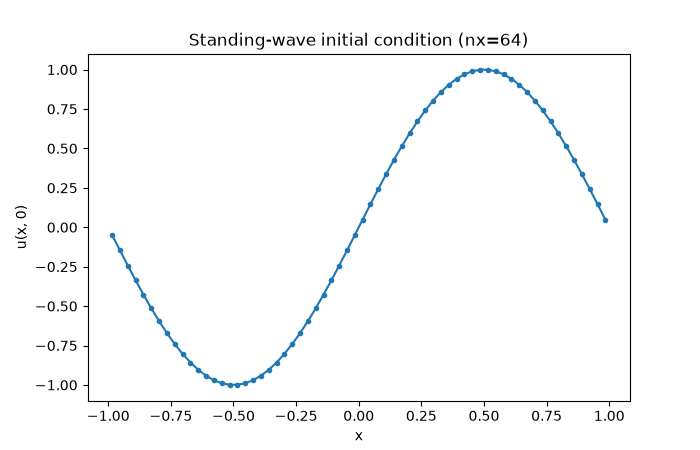

In [2]:
from warpSPH.configurations import WaveEquationConfig, buildConfig
from warpSPH.sample.bySamplingScheme import sampleParticles
from warpSPH.schemes.waveEquation import f_wave_equation
from warpSPH.systems.waveSystem import WaveSystemStatev3, WaveSystemv3
from warpSPH.utils import buildDomainDescription
from warpSPHCore import SupportScheme, buildVerletList

CFL_FACTOR = 0.1  # matches test_implicitWaveEquation.py's own default


def buildStandingWaveSystem(nx=32, dim=1, c=1.0, L=2.0, cflFactor=CFL_FACTOR):
    """A periodic 1-D (or dim-D) standing wave u(x,0)=sin(kx), v(x,0)=0,
    k=pi, wave speed c, zero damping -- the validation case this whole
    notebook explores solvers on.
    """
    domain = buildDomainDescription(l=L, dim=dim, periodic=True, device=DEVICE, dtype=DTYPE)
    config, _integrator = buildConfig(dim=dim, nx=nx, domain=domain, device=DEVICE,
                                      dtype=DTYPE, dx=L / nx, cflFactor=cflFactor)
    k = math.pi
    particles = sampleParticles(nx, config)
    x = particles.positions[:, 0]
    u0 = torch.sin(k * x)
    v0 = torch.zeros_like(u0)
    n = x.shape[0]
    state = WaveSystemStatev3(
        positions=particles.positions, supports=particles.supports, masses=particles.masses,
        densities=particles.densities, kinds=torch.zeros(n, device=DEVICE, dtype=torch.int32),
        materials=torch.zeros(n, device=DEVICE, dtype=torch.int32),
        UIDs=torch.arange(n, device=DEVICE, dtype=torch.int32), UIDcounter=n,
        u=u0, v=v0, c=torch.full_like(u0, c), damping=torch.zeros_like(u0),
    )
    adjacency = buildVerletList(state, config.domain, 1.0, SupportScheme.SuperSymmetric, None)
    system = WaveSystemv3(state=state, adjacency=adjacency, domain=config.domain,
                          t=torch.tensor(0.0, device=DEVICE, dtype=DTYPE))
    return system, config, k


schemeConfig = WaveEquationConfig()
print(schemeConfig)

_probe, _config, _k = buildStandingWaveSystem(nx=64)
plt.figure()
plt.plot(_probe.state.positions[:, 0].cpu(), _probe.state.u.cpu(), '.-')
plt.xlabel('x'); plt.ylabel('u(x, 0)'); plt.title('Standing-wave initial condition (nx=64)')
plt.show()


## 2. A ground-truth reference: hand-rolled conjugate gradients

Backward Euler applied to this system eliminates `v` algebraically (the PDE
is linear) down to one stage equation for `u`:

$$
u^{n+1} - \alpha\,\mathrm{Laplacian}(u^{n+1}) = \text{rhs}, \qquad
\alpha = \frac{dt^2 c^2}{1 + dt\cdot\text{damping}}
$$

`test_implicitWaveEquation.py` solves this *exact* `N`-dimensional equation
with a from-scratch CG (matrix-free, via `warpOperationJVP` directly — no
`warpSPHIntegrators` involved at all). We reuse that reference here as
ground truth: it's solving a genuinely *smaller* linear system than the
generic `2N`-dimensional coupled `(u, v)` DIRK stage system JFNK solves, so
agreement between the two is a real cross-check, not a tautology.


In [3]:
from typing import Callable, Optional, Tuple
from warpSPHCore import OperationProperties, WarpOperation, warpOperationJVP


def conjugateGradientSolve(matvec: Callable[[torch.Tensor], torch.Tensor], b: torch.Tensor,
                           x0: Optional[torch.Tensor] = None, tol: float = 1e-8,
                           maxiter: Optional[int] = None) -> Tuple[torch.Tensor, int]:
    x = x0.clone() if x0 is not None else torch.zeros_like(b)
    r = b - matvec(x)
    p = r.clone()
    rsOld = torch.dot(r, r)
    atol = tol * max(float(torch.linalg.norm(b)), 1.0)
    if maxiter is None:
        maxiter = b.shape[0] * 10
    for iteration in range(maxiter):
        if torch.sqrt(rsOld) < atol:
            return x, iteration
        Ap = matvec(p)
        alpha = rsOld / torch.dot(p, Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rsNew = torch.dot(r, r)
        if torch.sqrt(rsNew) < atol:
            return x, iteration + 1
        p = r + (rsNew / rsOld) * p
        rsOld = rsNew
    return x, maxiter


def implicitBackwardEulerStep(system, dt, config, schemeConfig, tol=1e-8):
    state = system.state
    props = OperationProperties(
        operation=WarpOperation.Laplacian, kernel=schemeConfig.kernel,
        supportMode=schemeConfig.supportMode, laplacianMode=schemeConfig.laplacianMode,
        gradientMode=schemeConfig.gradientMode,
    )

    def laplacian(p):
        return warpOperationJVP(system.state, props, system.domain, tangentQueryValues=p,
                                adjacency=system.adjacency)

    denom = 1.0 + dt * state.damping
    alpha = dt * dt * state.c ** 2 / denom
    rhs = state.u + dt * state.v / denom

    def matvec(p):
        return p - alpha * laplacian(p)

    uNext, _iters = conjugateGradientSolve(matvec, rhs, x0=state.u, tol=tol)
    vNext = (state.v + dt * state.c ** 2 * laplacian(uNext)) / denom

    from warpSPH.systems.waveSystem import WaveSystemStatev3, WaveSystemv3
    newState = WaveSystemStatev3(
        positions=state.positions, supports=state.supports, masses=state.masses,
        densities=state.densities, kinds=state.kinds, materials=state.materials,
        UIDs=state.UIDs, UIDcounter=state.UIDcounter,
        u=uNext, v=vNext, c=state.c, damping=state.damping,
    )
    return WaveSystemv3(state=newState, adjacency=system.adjacency, domain=system.domain,
                        t=system.t + dt)


# Sanity check: one CG step against the analytic solution.
cgSystem, cgConfig, k = buildStandingWaveSystem(nx=64)
dt_small = CFL_FACTOR * cgSystem.state.supports.max().item() / 1.0
cgResult = implicitBackwardEulerStep(cgSystem, dt_small, cgConfig, schemeConfig)
analytic = torch.sin(k * cgResult.state.positions[:, 0]) * math.cos(1.0 * k * dt_small)
print('CG one-step RMSE vs analytic:',
     torch.sqrt(torch.mean((cgResult.state.u - analytic) ** 2)).item())


Module warpSPHCore.coreOperations.wp_laplacian a649ef2 load on device 'cuda:0' took 4.38 ms  (cached)
CG one-step RMSE vs analytic: 0.0005354277673177421


## 3. The `NonlinearSolver` interface

Every implicit DIRK stage (`warpSPHIntegrators.dirk.DIRK`) needs to solve a
stage equation `Y = base_state + a_ii*dt*f(Y)` for the unknown `Y`. That's
handed to a `NonlinearSolver`:

```python
class NonlinearSolver(Protocol):
    def solve(self, step, y0, norm=None, **opts) -> SolveResult:
        ...  # drives y0 towards a fixed point of step, i.e. y == step(y)

class SolveResult(NamedTuple):
    y: Any            # the solver's answer
    converged: bool    # what "converged" means depends on the solver -- see below
    iterations: int
```

`step(y)` returns the *next* iterate — everything about `dt`, the tableau
coefficient `a_ii`, and the explicit part of the stage is closed over inside
`step`, so every solver in the ladder shares this one call shape.

### `FixedPointSolver` — Picard iteration (the registry default)

```python
FixedPointSolver(iterations: int = 2)
```

Runs `step` a **fixed** number of times, no matter what. With no `tol=`
passed to `solve(...)`, `converged=True` just means "completed its
schedule" — not that anything was actually verified. Two iterations reach
full *order* for the second-order DIRK tableaus (`NOTES.md` §3.1), but that
says nothing about whether the *residual* is actually small — see
Experiment 1 below. Diverges outside its own stability radius
(`|dt*a_ii*L| < 1`, `L` the local Lipschitz constant/Jacobian norm); more
iterations of a divergent map just diverge *faster*, they never help.

### `JFNKSolver` — Jacobian-free Newton-Krylov (opt-in, `JFNK_PLAN.md` Phase A)

```python
JFNKSolver(
    matvec: str = 'fd',            # 'fd' (finite-difference) or 'jvp' (exact)
    tol: float = 1e-8,             # Newton convergence: norm(Y, step(Y)) < tol
    max_iterations: int = 20,      # Newton *correction* budget
    gmres_tol: float = None,       # defaults to `tol`
    gmres_maxiter: int = None,     # defaults to the state's own flat length
    gmres_restart: int = 30,       # GMRES(m) restart length
    fd_eps: float = None,          # override the Knoll-Keyes FD step
    newton_tol: float = None,      # Newton's own outer check; defaults to `tol`
    newton_stagnation_ratio: float = 0.9,   # plateau early-exit (see the solver docstring)
    newton_stagnation_patience: int = 2,
    line_search: bool = False,     # backtracking on the trial residual
    line_search_min_step: float = 1e-2,
    preconditioner: Callable = None,     # Phase 2: 3-arg hook preconditioner(v, state, context)
    preconditioning: str = 'right',      # 'right': solve A.M.z = b, return x = M.z; 'left': solve M.A.x = M.b
    preconditioner_context: dict = None,  # static context merged into {'state': Y}
)
```

Every option above is also a `solve(...)` **kwarg**, i.e.
`solver_opts={'tol': 1e-6}` on a DIRK call overrides the constructor default
for that one call, matching `FixedPointSolver`'s own `opts.get(..., self.x)`
pattern.

Each outer (Newton) iteration: evaluate `step(Y)` once, check
`norm(Y, step(Y)) < tol`; if not converged, solve one Newton correction with
GMRES against a matrix-free Jacobian-vector product, and repeat. The number
of `step()` calls is `max_iterations + 1` in the worst case (one extra to
verify/report on the last correction). **Never opt into this by default** —
it's real machinery (flatten/unflatten, GMRES, a matvec choice) for a
problem `FixedPointSolver` already handles well in the non-stiff regime.
Nothing in the scheme registry ever picks it automatically.

**`matvec='fd'`** (default): `Jv ≈ (G(Y+εv) - G(Y))/ε`, works for *any*
`step`, no capability gate. `ε` is the standard Knoll-Keyes scaled step,
`sqrt(eps_machine)*(1+‖y‖)/‖v‖`.

**`matvec='jvp'`**: exact, via `torch.autograd.forward_ad`. Only exact when
`step` is built entirely from `warpSPHCore`'s six JVP-wrapped operators
(Density, Interpolate, Gradient, Divergence, Curl, Laplacian) plus
Covariance — which the wave equation's Laplacian call satisfies. For
anything else, this **raises `NotImplementedError` loudly** rather than
silently dropping the missing term — never caught anywhere in this stack.

`norm=None` (the default when `JFNKSolver.solve` is called directly, e.g.
Experiment 4 below) falls back to a plain relative L2 norm over the
flattened state, `‖a-b‖ / max(‖a‖, 1)`. Driven through
`getIntegrator(...)`/`DIRK`, `dirk.py` always supplies its own
Hairer-Wanner-weighted `norm` instead — a *different* scale, so a `tol`
tuned against one convention isn't directly portable to the other (see
Experiment 4).


### The four registered DIRK tableaus

```python
from warpSPHIntegrators import getIntegrator
getIntegrator('Backward Euler (implicit)')   # order 1, L-stable
getIntegrator('Implicit Midpoint')           # order 2, A-stable, symplectic (Picard default drifts -- see NOTES.md)
getIntegrator('Trapezoidal (Crank-Nicolson)')# order 2, A-stable (not L)
getIntegrator('SDIRK2')                      # order 2, L-stable
```

Calling one runs a full step:
`scheme(system, dt, f_wave_equation, config, schemeConfig, solver=...)` →
`IntegrationResult(state=..., stages=..., ...)`.


In [4]:
from warpSPHIntegrators import FixedPointSolver, JFNKSolver, get_reference_state, getIntegrator


def runStep(system, dt, config, schemeConfig, solver, schemeName='Backward Euler (implicit)'):
    scheme = getIntegrator(schemeName)
    return scheme(system, dt, f_wave_equation, config, schemeConfig, solver=solver)


# quick smoke test of every solver on one small step
_sys, _config, _k = buildStandingWaveSystem(nx=32)
dt0 = CFL_FACTOR * _sys.state.supports.max().item()
for name, solver in [
    ('Picard(2)', FixedPointSolver(iterations=2)),
    ('JFNK(fd)', JFNKSolver(matvec='fd')),
    ('JFNK(jvp)', JFNKSolver(matvec='jvp')),
]:
    s, c, _ = buildStandingWaveSystem(nx=32)
    r = runStep(s, dt0, c, schemeConfig, solver)
    print(f'{name:12s} u[:3] = {get_reference_state(r.state).u[:3].tolist()}')


Picard(2)    u[:3] = [-0.09742353111505508, -0.2885268032550812, -0.4685419797897339]


JFNK(fd)     u[:3] = [-0.09742709994316101, -0.2885373830795288, -0.4685591757297516]
JFNK(jvp)    u[:3] = [-0.09742709994316101, -0.2885373830795288, -0.4685591757297516]


## Experiment 1 — `dt` sweep: where Picard diverges and JFNK doesn't

`FixedPointSolver`'s stability radius is set by `dt*a_ii*L`, `L` the local
Lipschitz constant of `f` — here set by the Laplacian operator's spectral
radius, which scales like $c^2/h^2$. At `nx=32`, `L≈2`, the case's own
CFL-scaled `dt` is only about `6e-3`; we'll sweep `dt` from well below that
up past $10^3\times$ it.

We use `JFNK(jvp)` at a tight tolerance as the "truth" reference for this
sweep (rather than the CG solver above) precisely *because* it's solving
the same `2N`-dimensional system every other solver here solves — a fairer
apples-to-apples comparison than the CG reference's hand-eliminated
`N`-dimensional system. We'll cross-check against CG once at the end.


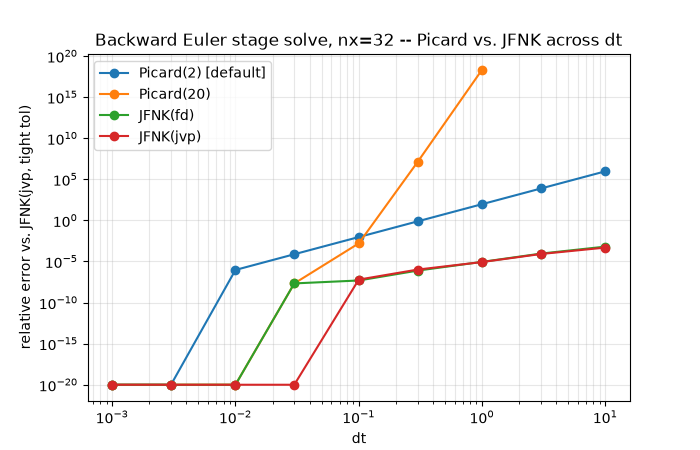

dt=  0.001  Picard(2) [default]=0.00e+00  Picard(20)=0.00e+00  JFNK(fd)=0.00e+00  JFNK(jvp)=0.00e+00
dt=  0.003  Picard(2) [default]=0.00e+00  Picard(20)=0.00e+00  JFNK(fd)=0.00e+00  JFNK(jvp)=0.00e+00
dt=  0.010  Picard(2) [default]=9.31e-07  Picard(20)=0.00e+00  JFNK(fd)=0.00e+00  JFNK(jvp)=0.00e+00
dt=  0.030  Picard(2) [default]=7.60e-05  Picard(20)=2.13e-08  JFNK(fd)=2.14e-08  JFNK(jvp)=0.00e+00
dt=  0.100  Picard(2) [default]=9.39e-03  Picard(20)=1.59e-03  JFNK(fd)=4.87e-08  JFNK(jvp)=6.23e-08
dt=  0.300  Picard(2) [default]=7.60e-01  Picard(20)=1.27e+07  JFNK(fd)=7.75e-07  JFNK(jvp)=1.03e-06
dt=  1.000  Picard(2) [default]=9.39e+01  Picard(20)=2.14e+18  JFNK(fd)=8.93e-06  JFNK(jvp)=8.53e-06
dt=  3.000  Picard(2) [default]=7.60e+03  Picard(20)=inf  JFNK(fd)=9.09e-05  JFNK(jvp)=8.12e-05
dt= 10.000  Picard(2) [default]=9.39e+05  Picard(20)=inf  JFNK(fd)=6.44e-04  JFNK(jvp)=4.91e-04


In [5]:
def relError(u, uRef):
    return float(torch.linalg.norm(u - uRef) / torch.linalg.norm(uRef))


dts = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
nx = 32
solvers = {
    'Picard(2) [default]': lambda: FixedPointSolver(iterations=2),
    'Picard(20)': lambda: FixedPointSolver(iterations=20),
    'JFNK(fd)': lambda: JFNKSolver(matvec='fd', tol=1e-8, max_iterations=15),
    'JFNK(jvp)': lambda: JFNKSolver(matvec='jvp', tol=1e-8, max_iterations=15),
}

results = {name: [] for name in solvers}
for dt in dts:
    refSys, refConfig, _k = buildStandingWaveSystem(nx=nx)
    refResult = runStep(refSys, dt, refConfig, schemeConfig, JFNKSolver(matvec='jvp', tol=1e-10, max_iterations=20))
    uRef = get_reference_state(refResult.state).u

    for name, factory in solvers.items():
        s, c, _ = buildStandingWaveSystem(nx=nx)
        r = runStep(s, dt, c, schemeConfig, factory())
        u = get_reference_state(r.state).u
        err = relError(u, uRef) if torch.isfinite(u).all() else float('inf')
        results[name].append(err)

fig, ax = plt.subplots()
for name, errs in results.items():
    plotErrs = [e if e > 0 else 1e-20 for e in errs]  # log-safe
    ax.loglog(dts, plotErrs, 'o-', label=name)
ax.set_xlabel('dt'); ax.set_ylabel('relative error vs. JFNK(jvp, tight tol)')
ax.set_title(f'Backward Euler stage solve, nx={nx} -- Picard vs. JFNK across dt')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.show()

for dt, *rows in zip(dts, *results.values()):
    print(f'dt={dt:7.3f}  ' + '  '.join(f'{n}={v:.2e}' for n, v in zip(results, rows)))


**What to expect**: `Picard(2)`'s error grows roughly linearly with `dt`
(it never diverges *outright* at 2 iterations — it just returns something
increasingly wrong). `Picard(20)` tracks `Picard(2)` at small `dt`, but past
the stability radius it **diverges explosively** with the extra iterations
(easily `1e11`+ by `dt=1`, `inf` — float32 overflow — by `dt≈2-5`): running
a divergent fixed-point map harder makes it *more* wrong, not less. Both
`JFNK` variants stay within a few `1e-6`–`1e-7` of the reference at *every*
`dt` in the sweep — Newton on this exactly-linear problem is exact, modulo
GMRES's own tolerance, regardless of stiffness.

This is `JFNK_PLAN.md` A6's own validation case, generalized into a sweep:
`tests/test_implicitWaveEquation.py::test_picardDivergesWhereJFNKStaysBoundedOnAStiffStep`
checks exactly this at a single `dt=2.0`.


## Experiment 2 — all four DIRK tableaus, checked against the analytic solution

Standing-wave error at a *fixed*, CFL-scaled `dt` is dominated by **spatial**
(SPH) discretization error at this resolution, not temporal truncation
error — so this isn't a clean way to measure a tableau's temporal order (for
that, `warpSPHIntegrators`'s own point-ODE probes in `testing.py`
(`oscillator`/`forced`/`damped`) are the right tool, as `test_dirk.py` uses).
What *this* case is good for is the same check
`test_implicitStandingWaveErrorShrinksWithResolution` already runs for the
CG-based backward Euler path: does the standing wave converge to the
analytic solution as resolution increases, for every tableau, driven by
JFNK instead of the hand-eliminated CG solve?


Backward Euler (implicit)        ['1.169e-02', '4.606e-03', '2.774e-03']


Implicit Midpoint                ['1.075e-02', '4.327e-03', '2.711e-03']


Trapezoidal (Crank-Nicolson)     ['1.075e-02', '4.327e-03', '2.711e-03']


SDIRK2                           ['1.047e-02', '4.254e-03', '2.693e-03']


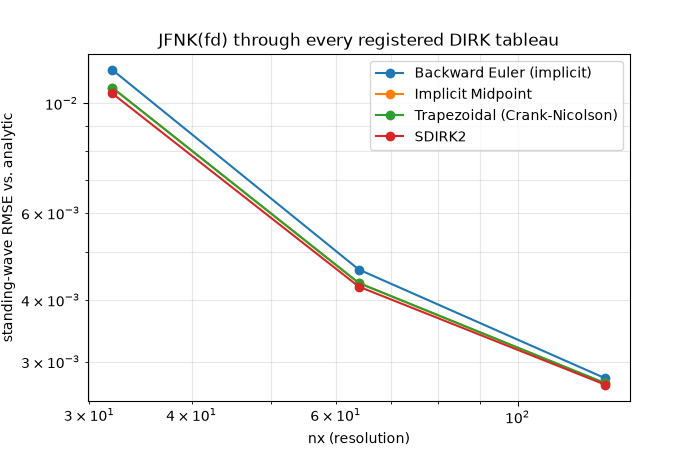

In [6]:
def standingWaveError(schemeName, solverFactory, nx=32, dim=1, c=1.0, L=2.0):
    system, config, k = buildStandingWaveSystem(nx, dim, c, L)
    hMax = system.state.supports.max().item()
    dt = CFL_FACTOR * hMax / c
    tEnd = (2 * math.pi / (c * k)) * 0.25
    nSteps = max(1, round(tEnd / dt))
    dtActual = tEnd / nSteps
    for _ in range(nSteps):
        result = runStep(system, dtActual, config, schemeConfig, solverFactory(), schemeName=schemeName)
        system = result.state
    x = system.state.positions[:, 0]
    analytic = torch.sin(k * x) * math.cos(c * k * tEnd)
    return torch.sqrt(torch.mean((system.state.u - analytic) ** 2)).item()


schemeNames = ['Backward Euler (implicit)', 'Implicit Midpoint', 'Trapezoidal (Crank-Nicolson)', 'SDIRK2']
resolutions = (32, 64, 128)

fig, ax = plt.subplots()
for schemeName in schemeNames:
    errs = [standingWaveError(schemeName, lambda: JFNKSolver(matvec='fd', tol=1e-9, max_iterations=15), nx=nx)
           for nx in resolutions]
    ax.loglog(resolutions, errs, 'o-', label=schemeName)
    print(f'{schemeName:32s} {["%.3e" % e for e in errs]}')
ax.set_xlabel('nx (resolution)'); ax.set_ylabel('standing-wave RMSE vs. analytic')
ax.set_title('JFNK(fd) through every registered DIRK tableau')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.show()


Error shrinks monotonically with resolution for all four tableaus, driven
entirely by `JFNKSolver` — the generic driver reaching the same qualitative
answer as the problem-specific CG path, for every registered implicit
scheme, not just backward Euler.


## Experiment 3 — FD vs. exact-JVP matvec: agreement and the concrete payoff

The two matvecs approximate the *same* linear operator ($J_G$, the Jacobian
of the stage residual $G(Y) = Y - \text{step}(Y)$). We check they agree to
FD's own truncation tolerance, and — the actual reason rung 3 exists at all
— that JVP needs no more (usually fewer) GMRES iterations to converge,
since it has no truncation error and no `ε` to tune.

This works directly with `fd_matvec`/`jvp_matvec`/`gmres` from
`warpSPHIntegrators.jfnk` — the same primitives `JFNKSolver` uses
internally, exposed so you can build custom solve loops (or just inspect
matvec behavior, as here) without going through the full solver.


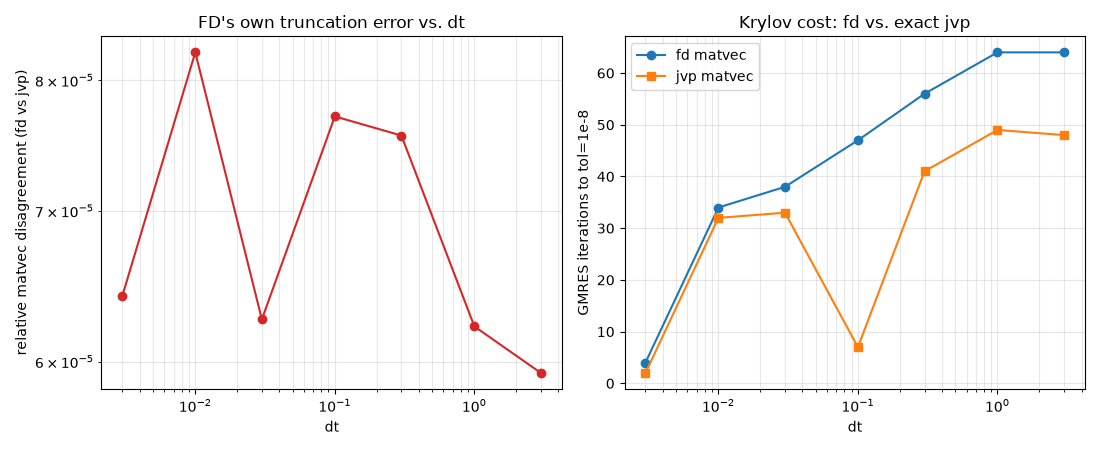

dt= 0.003  gmres(fd)=  4  gmres(jvp)=  2  matvec rel.diff=6.42e-05
dt= 0.010  gmres(fd)= 34  gmres(jvp)= 32  matvec rel.diff=8.23e-05
dt= 0.030  gmres(fd)= 38  gmres(jvp)= 33  matvec rel.diff=6.26e-05
dt= 0.100  gmres(fd)= 47  gmres(jvp)=  7  matvec rel.diff=7.71e-05
dt= 0.300  gmres(fd)= 56  gmres(jvp)= 41  matvec rel.diff=7.56e-05
dt= 1.000  gmres(fd)= 64  gmres(jvp)= 49  matvec rel.diff=6.22e-05
dt= 3.000  gmres(fd)= 64  gmres(jvp)= 48  matvec rel.diff=5.93e-05


In [7]:
from warpSPHIntegrators.fields import flatten_integrated
from warpSPHIntegrators.jfnk import fd_matvec, gmres, jvp_matvec
from warpSPHIntegrators.util import updateStateEuler, updateStep


def backwardEulerStageStepFn(system, dt, config, schemeConfig):
    """The same stage map DIRK builds internally for backward Euler's one
    implicit stage (a_ii=1): Y -> y0 + dt*f(Y). Exposed here so the matvecs
    can be driven directly, outside of JFNKSolver's own Newton loop.
    """
    y0 = system.initializeNewState()
    y0.t = float(system.t) + dt

    def step_fn(Y):
        Y.t = y0.t
        k, r = updateStep(system, Y, dt, f_wave_equation, config, schemeConfig)
        return updateStateEuler(y0, k, dt, copyState=True)

    return y0, step_fn


dts = [0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
iters_fd, iters_jvp, matvec_diff = [], [], []
torch.manual_seed(0)
for dt in dts:
    system, config, _k = buildStandingWaveSystem(nx=32)
    y0, step_fn = backwardEulerStageStepFn(system, dt, config, schemeConfig)
    y_flat = flatten_integrated(y0)
    G_y = y_flat - flatten_integrated(step_fn(y0))

    mv_fd = fd_matvec(step_fn, y0, y_flat, G_y)
    mv_jvp = jvp_matvec(step_fn, y0)

    v = torch.randn_like(y_flat)
    matvec_diff.append(float(torch.linalg.norm(mv_fd(v) - mv_jvp(v)) / torch.linalg.norm(mv_jvp(v))))

    _delta_fd, n_fd = gmres(mv_fd, -G_y, tol=1e-8, maxiter=y_flat.numel())
    _delta_jvp, n_jvp = gmres(mv_jvp, -G_y, tol=1e-8, maxiter=y_flat.numel())
    iters_fd.append(n_fd)
    iters_jvp.append(n_jvp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.loglog(dts, matvec_diff, 'o-', color=colors[3])
ax1.set_xlabel('dt'); ax1.set_ylabel('relative matvec disagreement (fd vs jvp)')
ax1.set_title("FD's own truncation error vs. dt")
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(dts, iters_fd, 'o-', label='fd matvec')
ax2.semilogx(dts, iters_jvp, 's-', label='jvp matvec')
ax2.set_xlabel('dt'); ax2.set_ylabel('GMRES iterations to tol=1e-8')
ax2.set_title('Krylov cost: fd vs. exact jvp')
ax2.legend(); ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

for dt, nf, nj, d in zip(dts, iters_fd, iters_jvp, matvec_diff):
    print(f'dt={dt:6.3f}  gmres(fd)={nf:3d}  gmres(jvp)={nj:3d}  matvec rel.diff={d:.2e}')


Two things to read off this plot: (1) the FD/JVP matvec disagreement grows
with `dt` (FD's own `ε` is tuned to the current iterate/direction, not to
`dt`, so as the operator's scale grows with `dt` the fixed-precision FD
formula loses relative accuracy) — never so large that FD becomes *wrong*
for GMRES's purposes, just less exact, exactly as `JFNK_PLAN.md` A6
anticipated ("agree to FD's own truncation tolerance"). (2) JVP never needs
*more* Krylov iterations than FD to reach the same tolerance, and at some
`dt` values needs meaningfully fewer — the concrete reason to reach for
`matvec='jvp'` once you know your `step` qualifies.


## Experiment 4 — solver knobs: `tol` and `max_iterations` in float32

`JFNKSolver.solve(step, y0)` can be called directly (bypassing DIRK/`norm`
entirely) to see exactly what `SolveResult` reports for a given `tol`/
`max_iterations`. Two things worth knowing before you tune these on a real
problem:

- **`tol` has a float32 floor.** This state is `float32` throughout (the
  whole `warpSPH`/`warpSPHCore` stack defaults to it); asking for a relative
  tolerance tighter than roughly float32's own epsilon (~`1.2e-7`) simply
  can't be satisfied — `SolveResult.converged` will be `False` and
  `iterations` will hit your `max_iterations` cap every time, not because
  anything is wrong, but because the target is below the noise floor of the
  arithmetic itself.
- **`max_iterations` is a correction *budget*, not a call count.** The
  number of `step()` evaluations is `max_iterations + 1` in the
  non-converged case (one more to report on the last correction) — see
  `JFNKSolver`'s own docstring.


In [8]:
system, config, _k = buildStandingWaveSystem(nx=32)
dt = 0.1
y0, step_fn = backwardEulerStageStepFn(system, dt, config, schemeConfig)

print('--- varying tol (max_iterations=20) ---')
for tol in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    result = JFNKSolver(matvec='fd', tol=tol, max_iterations=20).solve(step_fn, y0)
    print(f'  tol={tol:9.1e}  converged={result.converged!s:5s}  iterations={result.iterations}')

print('--- varying max_iterations (tol=1e-10, unreachable in float32) ---')
for max_it in [1, 2, 5, 20]:
    result = JFNKSolver(matvec='fd', tol=1e-10, max_iterations=max_it).solve(step_fn, y0)
    print(f'  max_iterations={max_it:3d}  converged={result.converged!s:5s}  iterations={result.iterations}')


--- varying tol (max_iterations=20) ---
  tol=  1.0e-02  converged=True   iterations=2
  tol=  1.0e-04  converged=True   iterations=3
  tol=  1.0e-06  converged=True   iterations=3
  tol=  1.0e-08  converged=True   iterations=6


  tol=  1.0e-10  converged=True   iterations=5
--- varying max_iterations (tol=1e-10, unreachable in float32) ---
  max_iterations=  1  converged=False  iterations=2


  max_iterations=  2  converged=False  iterations=3
  max_iterations=  5  converged=True   iterations=5


  max_iterations= 20  converged=True   iterations=5


## Experiment 5 — Preconditioned JFNK (roadmap Phase 2)

Experiments 1-4 take GMRES's iteration count as given. **Phase 2** of
`warpSPHIntegrators`' implicit roadmap (2026-09-09) added a knob to control
it: an optional **preconditioner** on both `gmres(...)` and `JFNKSolver`.
The caller-facing contract is a 3-argument callable

```python
preconditioner(v, state, context) -> vector
```

applied inside the GMRES loop: `state` is the current Newton iterate `Y`,
and `context` is `{'state': Y, **preconditioner_context}`. The result should
approximate `J_G(Y)^{-1} v` — the inverse of the stage-residual Jacobian at
the current iterate — using **operator applications only** (one SPH operator
apply is the unit of cost; no dense matrix is ever formed).
`preconditioning='right'` (the default) solves `A·M·z = b` and returns
`x = M·z`, with GMRES checking the **true** residual `b − A·x`;
`preconditioning='left'` solves `M·A·x = M·b` against the preconditioned
rhs. With no preconditioner — or with the shipped `identity_preconditioner`
— the solve is bit-for-bit what it was before the hook existed.

For this case the natural choice is the **block-lower-triangular factor** of
the backward-Euler stage Jacobian. With `a_ii = 1` (backward Euler), the
stage residual `G(Y) = Y − y0 − dt·f(Y)` has Jacobian

$$
J_G = \begin{bmatrix} I & -dt\, I \\ -dt\, c^2\,\mathrm{Lap} & I + dt\cdot\mathrm{damping}\, I \end{bmatrix}
$$

whose lower block-triangular part inverts as

$$
L^{-1} \begin{bmatrix} b_u \\ b_v \end{bmatrix}
= \begin{bmatrix} b_u \\ \dfrac{b_v + dt\, c^2\,\mathrm{Lap}(b_u)}{1 + dt\cdot\mathrm{damping}} \end{bmatrix}
$$

— one `warpOperationJVP` Laplacian apply per application, exactly the
operator the stage solve itself uses. (For a general SDIRK stage with
coefficient `a_ii`, replace `dt` by `a_ii*dt` in both places — Experiment 6
does exactly that for `SDIRK2` on the 2-D case.)


fd  : GMRES iterations   34 ->  12   solution agree 7.5e-04
jvp : GMRES iterations   32 ->   6   solution agree 3.5e-07


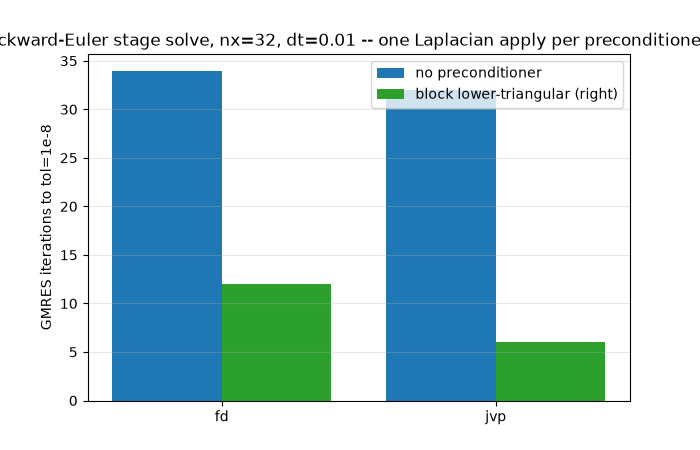

In [9]:
from warpSPHCore import OperationProperties, WarpOperation, warpOperationJVP


def laplacianMatvec(system, schemeConfig):
    """p -> Laplacian(p) via warpOperationJVP -- the only warpSPHCore call
    the preconditioner below needs (the same operator the stage solve uses)."""
    props = OperationProperties(
        operation=WarpOperation.Laplacian, kernel=schemeConfig.kernel,
        supportMode=schemeConfig.supportMode, laplacianMode=schemeConfig.laplacianMode,
        gradientMode=schemeConfig.gradientMode,
    )

    def laplacian(p):
        return warpOperationJVP(system.state, props, system.domain, tangentQueryValues=p,
                                adjacency=system.adjacency)
    return laplacian


def blockLowerTriangularPreconditioner(system, dt, a_ii, schemeConfig):
    """Phase 2's hook, built for this case: returns (preconditioner, context).

    `preconditioner(v, state, context)` approximates J_G(Y)^{-1} at the
    current Newton iterate `state`: per-particle `c`/`damping` are read off
    the iterate itself (that's the 3-arg contract), while `dt`, `a_ii`, the
    block size and the Laplacian matvec -- all fixed for the step -- ride in
    `context`.
    """
    n = system.state.u.shape[0]
    laplacian = laplacianMatvec(system, schemeConfig)

    def preconditioner(v, state, context):
        s = get_reference_state(state)
        u_block = v[:n]
        denom = 1.0 + context['a_ii'] * context['dt'] * s.damping
        v_block = (v[n:] + context['a_ii'] * context['dt'] * s.c ** 2 * laplacian(u_block)) / denom
        return torch.cat([u_block, v_block])

    return preconditioner, {'dt': dt, 'a_ii': a_ii, 'n': n, 'laplacian': laplacian}


dt = 0.01
system, config, _k = buildStandingWaveSystem(nx=32)
y0, step_fn = backwardEulerStageStepFn(system, dt, config, schemeConfig)
y_flat = flatten_integrated(y0)
G_y = y_flat - flatten_integrated(step_fn(y0))

preconditioner, context = blockLowerTriangularPreconditioner(system, dt, a_ii=1.0, schemeConfig=schemeConfig)

data = {}
for matvec in ('fd', 'jvp'):
    mv = fd_matvec(step_fn, y0, y_flat, G_y) if matvec == 'fd' else jvp_matvec(step_fn, y0)
    x_ref, it_ref = gmres(mv, -G_y, tol=1e-8, maxiter=y_flat.numel())
    x_prec, it_prec = gmres(mv, -G_y, tol=1e-8, maxiter=y_flat.numel(),
                            preconditioner=lambda v: preconditioner(v, system, context),
                            preconditioning='right')
    data[matvec] = (x_ref, it_ref, x_prec, it_prec)
    print(f'{matvec:4s}: GMRES iterations {it_ref:4d} -> {it_prec:3d}   '
          f'solution agree {(x_prec - x_ref).norm().item() / x_ref.norm().item():.1e}')

fig, ax = plt.subplots()
xpos = np.arange(len(data))
ax.bar(xpos - 0.2, [data[m][1] for m in data], width=0.4, label='no preconditioner', color=colors[0])
ax.bar(xpos + 0.2, [data[m][3] for m in data], width=0.4,
       label='block lower-triangular (right)', color=colors[2])
ax.set_xticks(xpos, list(data))
ax.set_ylabel('GMRES iterations to tol=1e-8')
ax.set_title(f'Backward-Euler stage solve, nx=32, dt={dt} -- one Laplacian apply per preconditioner call')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.show()


**What to expect**: a roughly 3× cut for the FD matvec and ~5× for the exact
JVP one (measured at this `dt` in float32: 34→12 and 32→6, run-to-run ±a
couple of iterations), both solves landing on the same fixed point. The
point is structural, not a constant: right-preconditioning by the block
lower factor turns `J_G` into `I` plus a single off-diagonal block, so the
`2N` coupled (u, v) system reduces to the `N`-dimensional Schur operator for
`u` — the exact operator the hand-eliminated CG of section 2 solves. The
*unpreconditioned* count is the one that tracks the full operator's
eigenvalue spread as `dt` and resolution grow; the preconditioned count
tracks only the Schur spread.


In [10]:
# End to end: the same hook on JFNKSolver itself, driven through getIntegrator.
sys_ref, cfg_ref, _ = buildStandingWaveSystem(nx=32)
res_ref = runStep(sys_ref, dt, cfg_ref, schemeConfig,
                  solver=JFNKSolver(matvec='jvp', tol=1e-8, max_iterations=15))

sys_prec, cfg_prec, _ = buildStandingWaveSystem(nx=32)
preconditioner, context = blockLowerTriangularPreconditioner(sys_prec, dt, a_ii=1.0, schemeConfig=schemeConfig)
res_prec = runStep(sys_prec, dt, cfg_prec, schemeConfig,
                   solver=JFNKSolver(matvec='jvp', tol=1e-8, max_iterations=15,
                                     preconditioner=preconditioner, preconditioning='right',
                                     preconditioner_context=context))

d_ref, d_prec = res_ref.solver_diagnostics[0], res_prec.solver_diagnostics[0]
print(f'GMRES iterations: {d_ref.gmres_iterations} -> {d_prec.gmres_iterations}   '
      f'(rhs_evaluations {d_ref.rhs_evaluations} -> {d_prec.rhs_evaluations})')

u_ref = get_reference_state(res_ref.state).u
u_prec = get_reference_state(res_prec.state).u
print(f'preconditioned vs. unpreconditioned u: rel diff '
      f'{(u_prec - u_ref).norm().item() / u_ref.norm().item():.1e}')


GMRES iterations: 33 -> 7   (rhs_evaluations 3 -> 3)
preconditioned vs. unpreconditioned u: rel diff 0.0e+00


The preconditioned solve reports ~5× fewer GMRES iterations end-to-end
(33→7 at this `dt`) and lands on the *same* answer — the stage equation has
one fixed point; both solves just get there with different Krylov effort
(each within its own `tol`). `result.solver_diagnostics[0].gmres_iterations`
is the per-stage count the DIRK driver collects for exactly this kind of
accounting.

**Where the same setup lives as a test**: `warpSPH/tests/test_implicitWaveEquation.py`
(Step 7) pins the same two assertions — the iteration cut and agreement
with the unpreconditioned and CG references — as a regression test; the
library-side contract (identity bitwise-equivalence, left vs. right,
state/context plumbing, the `diagonal_preconditioner` helper) is in
`warpSPHIntegrators/tests/test_preconditioner.py`.

**A negative result worth knowing** (measured in the library suite): a
*scalar* diagonal preconditioner does nothing on this uniform constant-`c`,
zero-damping case — it rescales the spectrum without changing its *spread*,
which is all GMRES sees. Diagonal (per-DOF) preconditioning pays off when
the stiffness varies by particle — the realistic SPH situation, and exactly
what the 2-D `waveEquationCase` has (obstacle `c=0.5`, cosine border damping
up to ~43). Experiment 6 shows the same block factor on that registered
case.


## Experiment 6 — the same setup on the registered 2-D `waveEquationCase`

Experiment 5's case is deliberately uniform (constant `c`, zero damping) —
the minimal case where the setup can be read line by line. The registered
`waveEquationCase` (`warpSPH.cases.waveEquation`) is the *realistic* regime
where a preconditioner earns its keep, because the stage stiffness is
genuinely per-particle: `c` drops to `0.5×` ambient inside the obstacle,
`damping` reaches ~43 at the cosine absorbing border, and at a `dt` well
past the explicit default the unpreconditioned stage operator
`I − a_ii·dt·J_f` has a wide eigenvalue spread — the Laplacian's `~h^{-2}`
content, the obstacle's reduced `c`, and the strong border damping all at
once. GMRES's iteration count tracks exactly that spread.

The setup is the one from Experiment 5, with SDIRK2's own `a_ii` in place
of backward Euler's 1 (one Laplacian apply per call, no dense matrix
anywhere):

$$
L^{-1} \begin{bmatrix} b_u \\ b_v \end{bmatrix}
= \begin{bmatrix} b_u \\ \dfrac{b_v + a_{ii}\,dt\, c^2\,\mathrm{Lap}(b_u)}{1 + a_{ii}\,dt\cdot\mathrm{damping}} \end{bmatrix},
\qquad a_{ii}(\text{SDIRK2}) = 1 - \tfrac{\sqrt{2}}{2} \approx 0.2929
$$

Per-particle `c`/`damping` are read off the current iterate (that's what
the 3-arg contract is for); `dt`, `a_ii` and the Laplacian matvec are fixed
for the step, so they ride in the context.


nx=64 -> 4096 particles, default dt=0.01250
c range [0.500, 1.000], damping range [0.000, 43.295]
Module warpSPHCore.coreOperations.wp_laplacian 344f354 load on device 'cuda:0' took 6.36 ms  (cached)


no preconditioner: 759 total GMRES iters over 6 stages, wall 1.85s, per-stage [146, 122, 188, 125, 99, 79]


preconditioned:    263 total GMRES iters over 6 stages, wall 0.71s, per-stage [42, 61, 30, 64, 36, 30]


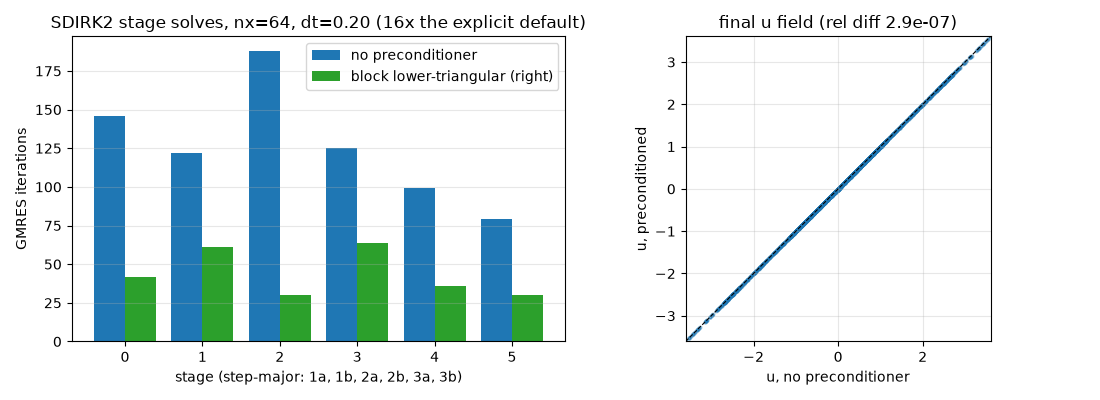

total GMRES iterations: 759 -> 263 (2.9x)
wall time:              1.85s -> 0.71s (2.6x)


In [11]:
import time
from warpSPH.cases.waveEquation import waveEquationCase
from warpSPH.runner import CaseSpec
from warpSPH.runner.runner import buildContext
from warpSPHCore import OperationProperties, WarpOperation, warpOperationJVP


def blockWavePreconditioner(system, dt, a_ii, schemeConfig):
    """(preconditioner, context) -- the block-lower-triangular stage factor
    for this case: one warpOperationJVP Laplacian apply per call, with
    per-particle c/damping read off the current Newton iterate."""
    n = system.state.u.shape[0]
    props = OperationProperties(
        operation=WarpOperation.Laplacian, kernel=schemeConfig.kernel,
        supportMode=schemeConfig.supportMode, laplacianMode=schemeConfig.laplacianMode,
        gradientMode=schemeConfig.gradientMode,
    )

    def laplacian(p):
        return warpOperationJVP(system.state, props, system.domain, tangentQueryValues=p,
                                adjacency=system.adjacency)

    def preconditioner(v, state, context):
        s = get_reference_state(state)
        u_block = v[:n]
        denom = 1.0 + context['a_ii'] * context['dt'] * s.damping
        v_block = (v[n:] + context['a_ii'] * context['dt'] * s.c ** 2 * laplacian(u_block)) / denom
        return torch.cat([u_block, v_block])

    return preconditioner, {'dt': dt, 'a_ii': a_ii, 'n': n, 'laplacian': laplacian}


def buildCaseSystem(dt):
    spec = CaseSpec(caseName=waveEquationCase.name, scheme=waveEquationCase.scheme,
                    params=dict(waveEquationCase.params)).merged(**waveEquationCase.defaults)
    spec = spec.merged(nx=64, quiet=True, progress=False, integrationScheme='SDIRK2', dt=dt)
    ctx = buildContext(waveEquationCase, spec)
    waveEquationCase.configureScheme(ctx)
    system = waveEquationCase.buildSystem(ctx)
    waveEquationCase.initialConditions(ctx, system)
    return ctx, system


def stepSystem(ctx, system, dt, nSteps, solver):
    """Unrolled step loop -> (finalState, per-stage GMRES iterations, wall time)."""
    state = system.initializeNewState()
    iters, wall = [], 0.0
    for _ in range(nSteps):
        t0 = time.perf_counter()
        result = ctx.integrator.function(state=state, f=ctx.stepFunction, dt=dt,
                                         config=ctx.config, schemeConfig=ctx.schemeConfig,
                                         verbose=False, solver=solver)
        wall += time.perf_counter() - t0
        state = result.state
        iters.extend(d.gmres_iterations for d in result.solver_diagnostics if d is not None)
    return state, iters, wall


# preview build at the case's own defaults: read the CFL dt and the
# per-particle stiffness the preconditioner is about to exploit
_spec = CaseSpec(caseName=waveEquationCase.name, scheme=waveEquationCase.scheme,
                 params=dict(waveEquationCase.params)).merged(**waveEquationCase.defaults)
_spec = _spec.merged(nx=64, quiet=True, progress=False)
_ctx = buildContext(waveEquationCase, _spec)
waveEquationCase.configureScheme(_ctx)
_system = waveEquationCase.buildSystem(_ctx)
waveEquationCase.initialConditions(_ctx, _system)
DT_DEFAULT = _ctx.config.dt
print(f'nx=64 -> {_system.state.positions.shape[0]} particles, default dt={DT_DEFAULT:.5f}')
print(f'c range [{_system.state.c.min().item():.3f}, {_system.state.c.max().item():.3f}], '
      f'damping range [{_system.state.damping.min().item():.3f}, {_system.state.damping.max().item():.3f}]')

A_II_SDIRK2 = 1.0 - math.sqrt(2.0) / 2.0   # SDIRK2's own a_ii (0.2929)
DT_PREC = 16 * DT_DEFAULT                   # 0.2 -- 16x the explicit default, past RK4's stability limit
N_STEPS_PREC = 3

ctx0, sys0 = buildCaseSystem(DT_PREC)
state0, iters0, wall0 = stepSystem(ctx0, sys0, DT_PREC, N_STEPS_PREC,
                                   JFNKSolver(matvec='jvp', tol=1e-6, max_iterations=15))
print(f'no preconditioner: {sum(iters0)} total GMRES iters over {len(iters0)} stages, '
      f'wall {wall0:.2f}s, per-stage {iters0}')

ctx1, sys1 = buildCaseSystem(DT_PREC)
preconditioner, precContext = blockWavePreconditioner(sys1, DT_PREC, A_II_SDIRK2, ctx1.schemeConfig)
state1, iters1, wall1 = stepSystem(ctx1, sys1, DT_PREC, N_STEPS_PREC,
                                   JFNKSolver(matvec='jvp', tol=1e-6, max_iterations=15,
                                               preconditioner=preconditioner, preconditioning='right',
                                               preconditioner_context=precContext))
print(f'preconditioned:    {sum(iters1)} total GMRES iters over {len(iters1)} stages, '
      f'wall {wall1:.2f}s, per-stage {iters1}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
stageIdx = np.arange(len(iters0))
ax1.bar(stageIdx - 0.2, iters0, width=0.4, label='no preconditioner', color=colors[0])
ax1.bar(stageIdx + 0.2, iters1, width=0.4, label='block lower-triangular (right)', color=colors[2])
ax1.set_xlabel('stage (step-major: 1a, 1b, 2a, 2b, 3a, 3b)')
ax1.set_ylabel('GMRES iterations')
ax1.set_title(f'SDIRK2 stage solves, nx=64, dt={DT_PREC:.2f} ({DT_PREC / DT_DEFAULT:.0f}x the explicit default)')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

u0, u1 = state0.state.u.cpu(), state1.state.u.cpu()
ax2.scatter(u0.flatten(), u1.flatten(), s=4, alpha=0.3)
lims = [float(min(u0.min(), u1.min())), float(max(u0.max(), u1.max()))]
ax2.plot(lims, lims, 'k--', linewidth=0.8)
ax2.set_xlim(*lims); ax2.set_ylim(*lims)
ax2.set_xlabel('u, no preconditioner'); ax2.set_ylabel('u, preconditioned')
ax2.set_title(f'final u field (rel diff {(u1 - u0).norm().item() / u0.norm().item():.1e})')
ax2.set_aspect('equal'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'total GMRES iterations: {sum(iters0)} -> {sum(iters1)} ({sum(iters0) / sum(iters1):.1f}x)')
print(f'wall time:              {wall0:.2f}s -> {wall1:.2f}s ({wall0 / wall1:.1f}x)')


**What to expect**: at this `dt` the unpreconditioned stage solves run
~100-200 GMRES iterations each (per-stage: 146, 122, 188, 125, 99, 79); the
block factor brings them to ~30-60 (42, 61, 30, 64, 36, 30) — 759→263 total
iterations, a ~2.7× wall-time cut with the same matvec in both runs — and
the final `u` field agrees to solver tolerance (rel diff ~3e-7). The
stage-1-vs-stage-2 variation within each step is the two SDIRK solves
starting from different base states, not a property of the preconditioner.

This is the integration point the roadmap asked for: **operator-based, no
dense Jacobian** — the same pattern applies to any SPH case whose stage
stiffness a few operator applies can approximate. The cheapest rung is a
per-particle diagonal `1/(1 + a_ii·dt·damping)` (one elementwise divide,
already worth something on this case's damping spread); the block factor
above adds one Laplacian apply and captures the u→v coupling too.
`warpSPH/tests/test_implicitWaveEquation.py` (Step 7) pins "preconditioned
JFNK matches the unpreconditioned and CG references with fewer GMRES
iterations" as a regression test, and the library-side contract (identity
bitwise-equivalence, left vs. right, state/context plumbing) is in
`warpSPHIntegrators/tests/test_preconditioner.py`.


## Quick reference

| | `FixedPointSolver` | `JFNKSolver` |
|---|---|---|
| Registry default | **Yes**, every DIRK scheme | No — always `solver=JFNKSolver(...)` |
| Cost per stage | Fixed: `iterations` calls to `step` | Variable: up to `max_iterations+1` calls to `step`, each non-final one plus one `gmres` solve |
| Stiff problems | Diverges past `\|dt*a_ii*L\|<1`; more iterations make it *worse* | Designed for this — Newton on a linear residual is exact |
| Differentiable / CUDA-graph-capturable | Yes, by construction (fixed unroll depth) | Not evaluated here — branches on `norm`/`tol` |
| Constructor | `FixedPointSolver(iterations=2)` | `JFNKSolver(matvec='fd', tol=1e-8, max_iterations=20, gmres_tol=None, gmres_maxiter=None, gmres_restart=30, fd_eps=None, preconditioner=None, preconditioning='right', preconditioner_context=None)` |
| Per-call override | `solver_opts={'iterations': N, 'tol': ..., 'norm': ...}` | `solver_opts={'matvec': ..., 'tol': ..., 'max_iterations': ..., 'gmres_tol': ..., 'gmres_maxiter': ..., 'gmres_restart': ..., 'fd_eps': ..., 'preconditioner': ..., 'preconditioning': ..., 'preconditioner_context': ...}` |
| `converged` meaning | `True` if `tol=None` (schedule completed) or the tol check passed | `True` only if `norm(Y, step(Y)) < tol` was actually reached |

**Driving a DIRK scheme with a chosen solver:**
```python
from warpSPHIntegrators import getIntegrator, JFNKSolver
scheme = getIntegrator('Backward Euler (implicit)')  # or 'Implicit Midpoint' / 'Trapezoidal (Crank-Nicolson)' / 'SDIRK2'
result = scheme(system, dt, f_wave_equation, config, schemeConfig,
                solver=JFNKSolver(matvec='jvp', tol=1e-8))
# with the Experiment 5/6 preconditioner (3-arg hook, operator-based, no dense matrix):
result = scheme(system, dt, f_wave_equation, config, schemeConfig,
                solver=JFNKSolver(matvec='jvp', tol=1e-8,
                                  preconditioner=preconditioner, preconditioning='right',
                                  preconditioner_context=context))
result.state  # the new WaveSystemv3
```

**Low-level primitives** (`warpSPHIntegrators.fields` / `.jfnk`), useful for
custom solve loops or, as in Experiments 3-5 above, for inspecting solver
internals directly:

```python
from warpSPHIntegrators.fields import flatten_integrated, unflatten_integrated
from warpSPHIntegrators.jfnk import fd_matvec, jvp_matvec, gmres, identity_preconditioner, diagonal_preconditioner
```

**Further reading**: `JFNK_PLAN.md` (the full phased plan — Phases A and 2
are what this notebook exercises; the remaining phases build on it towards
making WCSPH's acoustic subsystem implicit), `NOTES.md` §3.4 (the solver
ladder this fits into) and §3.6 (the DIRK driver itself),
`warpSPH/tests/test_implicitWaveEquation.py` (the warpSPH-side test suite —
Step 7 is Experiment 5 as a regression test), `tests/test_jfnk.py` (unit
tests for the primitives used in Experiments 3-4) and
`tests/test_preconditioner.py` (Phase 2's contract), plus the warpSPH-side
notebooks `examples/wave/jfnk_solver_exploration.ipynb` (Experiments 1-4 in
the original home) and `examples/wave/waveCase_implicit_vs_explicit.ipynb`
(explicit vs. implicit through the `Case`/`CaseSpec` frontend).
